In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# import scipy.io
from poisson_glm_granger import compute_granger_causality, compute_optimal_lags
# from joblib import Parallel, delayed
from statsmodels.stats.multitest import multipletests
import pickle
import copy

In [2]:
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

In [3]:
conditions=['GO','SS','FS']

In [4]:
n_q=3
unit_labels=[]
region_labels=['C3','F4']
region_pcs={
    'C3': [2,4],
    'F4': [5,10]
}
for region in region_labels:
    for pc in region_pcs[region]:
        for q in range(n_q):
            unit_labels.append(f'{region}-PC{pc+1}-Q{q+1}')
n_units=len(unit_labels)

In [5]:
unit_labels

['C3-PC3-Q1',
 'C3-PC3-Q2',
 'C3-PC3-Q3',
 'C3-PC5-Q1',
 'C3-PC5-Q2',
 'C3-PC5-Q3',
 'F4-PC6-Q1',
 'F4-PC6-Q2',
 'F4-PC6-Q3',
 'F4-PC11-Q1',
 'F4-PC11-Q2',
 'F4-PC11-Q3']

In [6]:
t1_signed_gc_matrices={
    condition: np.zeros((n_units, n_units))*np.nan for condition in conditions
}
t1_diff_gc_matrices=np.zeros((n_units, n_units))*np.nan
t1_p_values_diff=np.zeros((n_units, n_units))*np.nan
for c3_pc in region_pcs['C3']:
    for f4_pc in region_pcs['F4']:
        fname=f'/home/qmoreau/schmidt_data/stop_go_bursts/output/connectivity_t1_c3pc{c3_pc+1}_f4pc{f4_pc+1}.npz'
        data=np.load(fname, allow_pickle=True)
        pc_unit_labels=data['unit_labels'][()]
        pc_n_units=len(pc_unit_labels)
        for condition in conditions:
            pc_signed_gc_matrix=np.mean(np.array(data['signed_gc_matrices'][()][condition]),axis=0)
            for pc_i in range(pc_n_units):
                for pc_j in range(pc_n_units):
                    i=unit_labels.index(pc_unit_labels[pc_i])
                    j=unit_labels.index(pc_unit_labels[pc_j])
                    t1_signed_gc_matrices[condition][i,j]=pc_signed_gc_matrix[pc_i,pc_j]
        pc_diff_gc_matrices=np.mean(data['diff_gc_matrices'][()],axis=0)
        pc_p_values_diff=data['p_values_diff'][()]
        for pc_i in range(pc_n_units):
            for pc_j in range(pc_n_units):
                i=unit_labels.index(pc_unit_labels[pc_i])
                j=unit_labels.index(pc_unit_labels[pc_j])
                t1_diff_gc_matrices[i,j] = pc_diff_gc_matrices[pc_i,pc_j]
                t1_p_values_diff[i,j] = pc_p_values_diff[pc_i,pc_j]

In [7]:
t2_signed_gc_matrices={
    condition: np.zeros((n_units, n_units))*np.nan for condition in conditions
}
t2_diff_gc_matrices=np.zeros((n_units, n_units))*np.nan
t2_p_values_diff=np.zeros((n_units, n_units))*np.nan
for c3_pc in region_pcs['C3']:
    for f4_pc in region_pcs['F4']:
        fname=f'/home/qmoreau/schmidt_data/stop_go_bursts/output/connectivity_t2_c3pc{c3_pc+1}_f4pc{f4_pc+1}.npz'
        data=np.load(fname, allow_pickle=True)
        pc_unit_labels=data['unit_labels'][()]
        pc_n_units=len(pc_unit_labels)
        for condition in conditions:
            pc_signed_gc_matrix=np.mean(np.array(data['signed_gc_matrices'][()][condition]),axis=0)
            for pc_i in range(pc_n_units):
                for pc_j in range(pc_n_units):
                    i=unit_labels.index(pc_unit_labels[pc_i])
                    j=unit_labels.index(pc_unit_labels[pc_j])
                    t2_signed_gc_matrices[condition][i,j]=pc_signed_gc_matrix[pc_i,pc_j]
        pc_diff_gc_matrices=np.mean(data['diff_gc_matrices'][()],axis=0)
        pc_p_values_diff=data['p_values_diff'][()]
        for pc_i in range(pc_n_units):
            for pc_j in range(pc_n_units):
                i=unit_labels.index(pc_unit_labels[pc_i])
                j=unit_labels.index(pc_unit_labels[pc_j])
                t2_diff_gc_matrices[i,j] = pc_diff_gc_matrices[pc_i,pc_j]
                t2_p_values_diff[i,j] = pc_p_values_diff[pc_i,pc_j]

In [8]:
t3_signed_gc_matrices={
    condition: np.zeros((n_units, n_units))*np.nan for condition in conditions
}
t3_diff_gc_matrices=np.zeros((n_units, n_units))*np.nan
t3_p_values_diff=np.zeros((n_units, n_units))*np.nan
for c3_pc in region_pcs['C3']:
    for f4_pc in region_pcs['F4']:
        fname=f'/home/qmoreau/schmidt_data/stop_go_bursts/output/connectivity_t3_c3pc{c3_pc+1}_f4pc{f4_pc+1}.npz'
        data=np.load(fname, allow_pickle=True)
        pc_unit_labels=data['unit_labels'][()]
        pc_n_units=len(pc_unit_labels)
        for condition in conditions:
            pc_signed_gc_matrix=np.mean(np.array(data['signed_gc_matrices'][()][condition]),axis=0)
            for pc_i in range(pc_n_units):
                for pc_j in range(pc_n_units):
                    i=unit_labels.index(pc_unit_labels[pc_i])
                    j=unit_labels.index(pc_unit_labels[pc_j])
                    t3_signed_gc_matrices[condition][i,j]=pc_signed_gc_matrix[pc_i,pc_j]
        pc_diff_gc_matrices=np.mean(data['diff_gc_matrices'][()],axis=0)
        pc_p_values_diff=data['p_values_diff'][()]
        for pc_i in range(pc_n_units):
            for pc_j in range(pc_n_units):
                i=unit_labels.index(pc_unit_labels[pc_i])
                j=unit_labels.index(pc_unit_labels[pc_j])
                t3_diff_gc_matrices[i,j] = pc_diff_gc_matrices[pc_i,pc_j]
                t3_p_values_diff[i,j] = pc_p_values_diff[pc_i,pc_j]

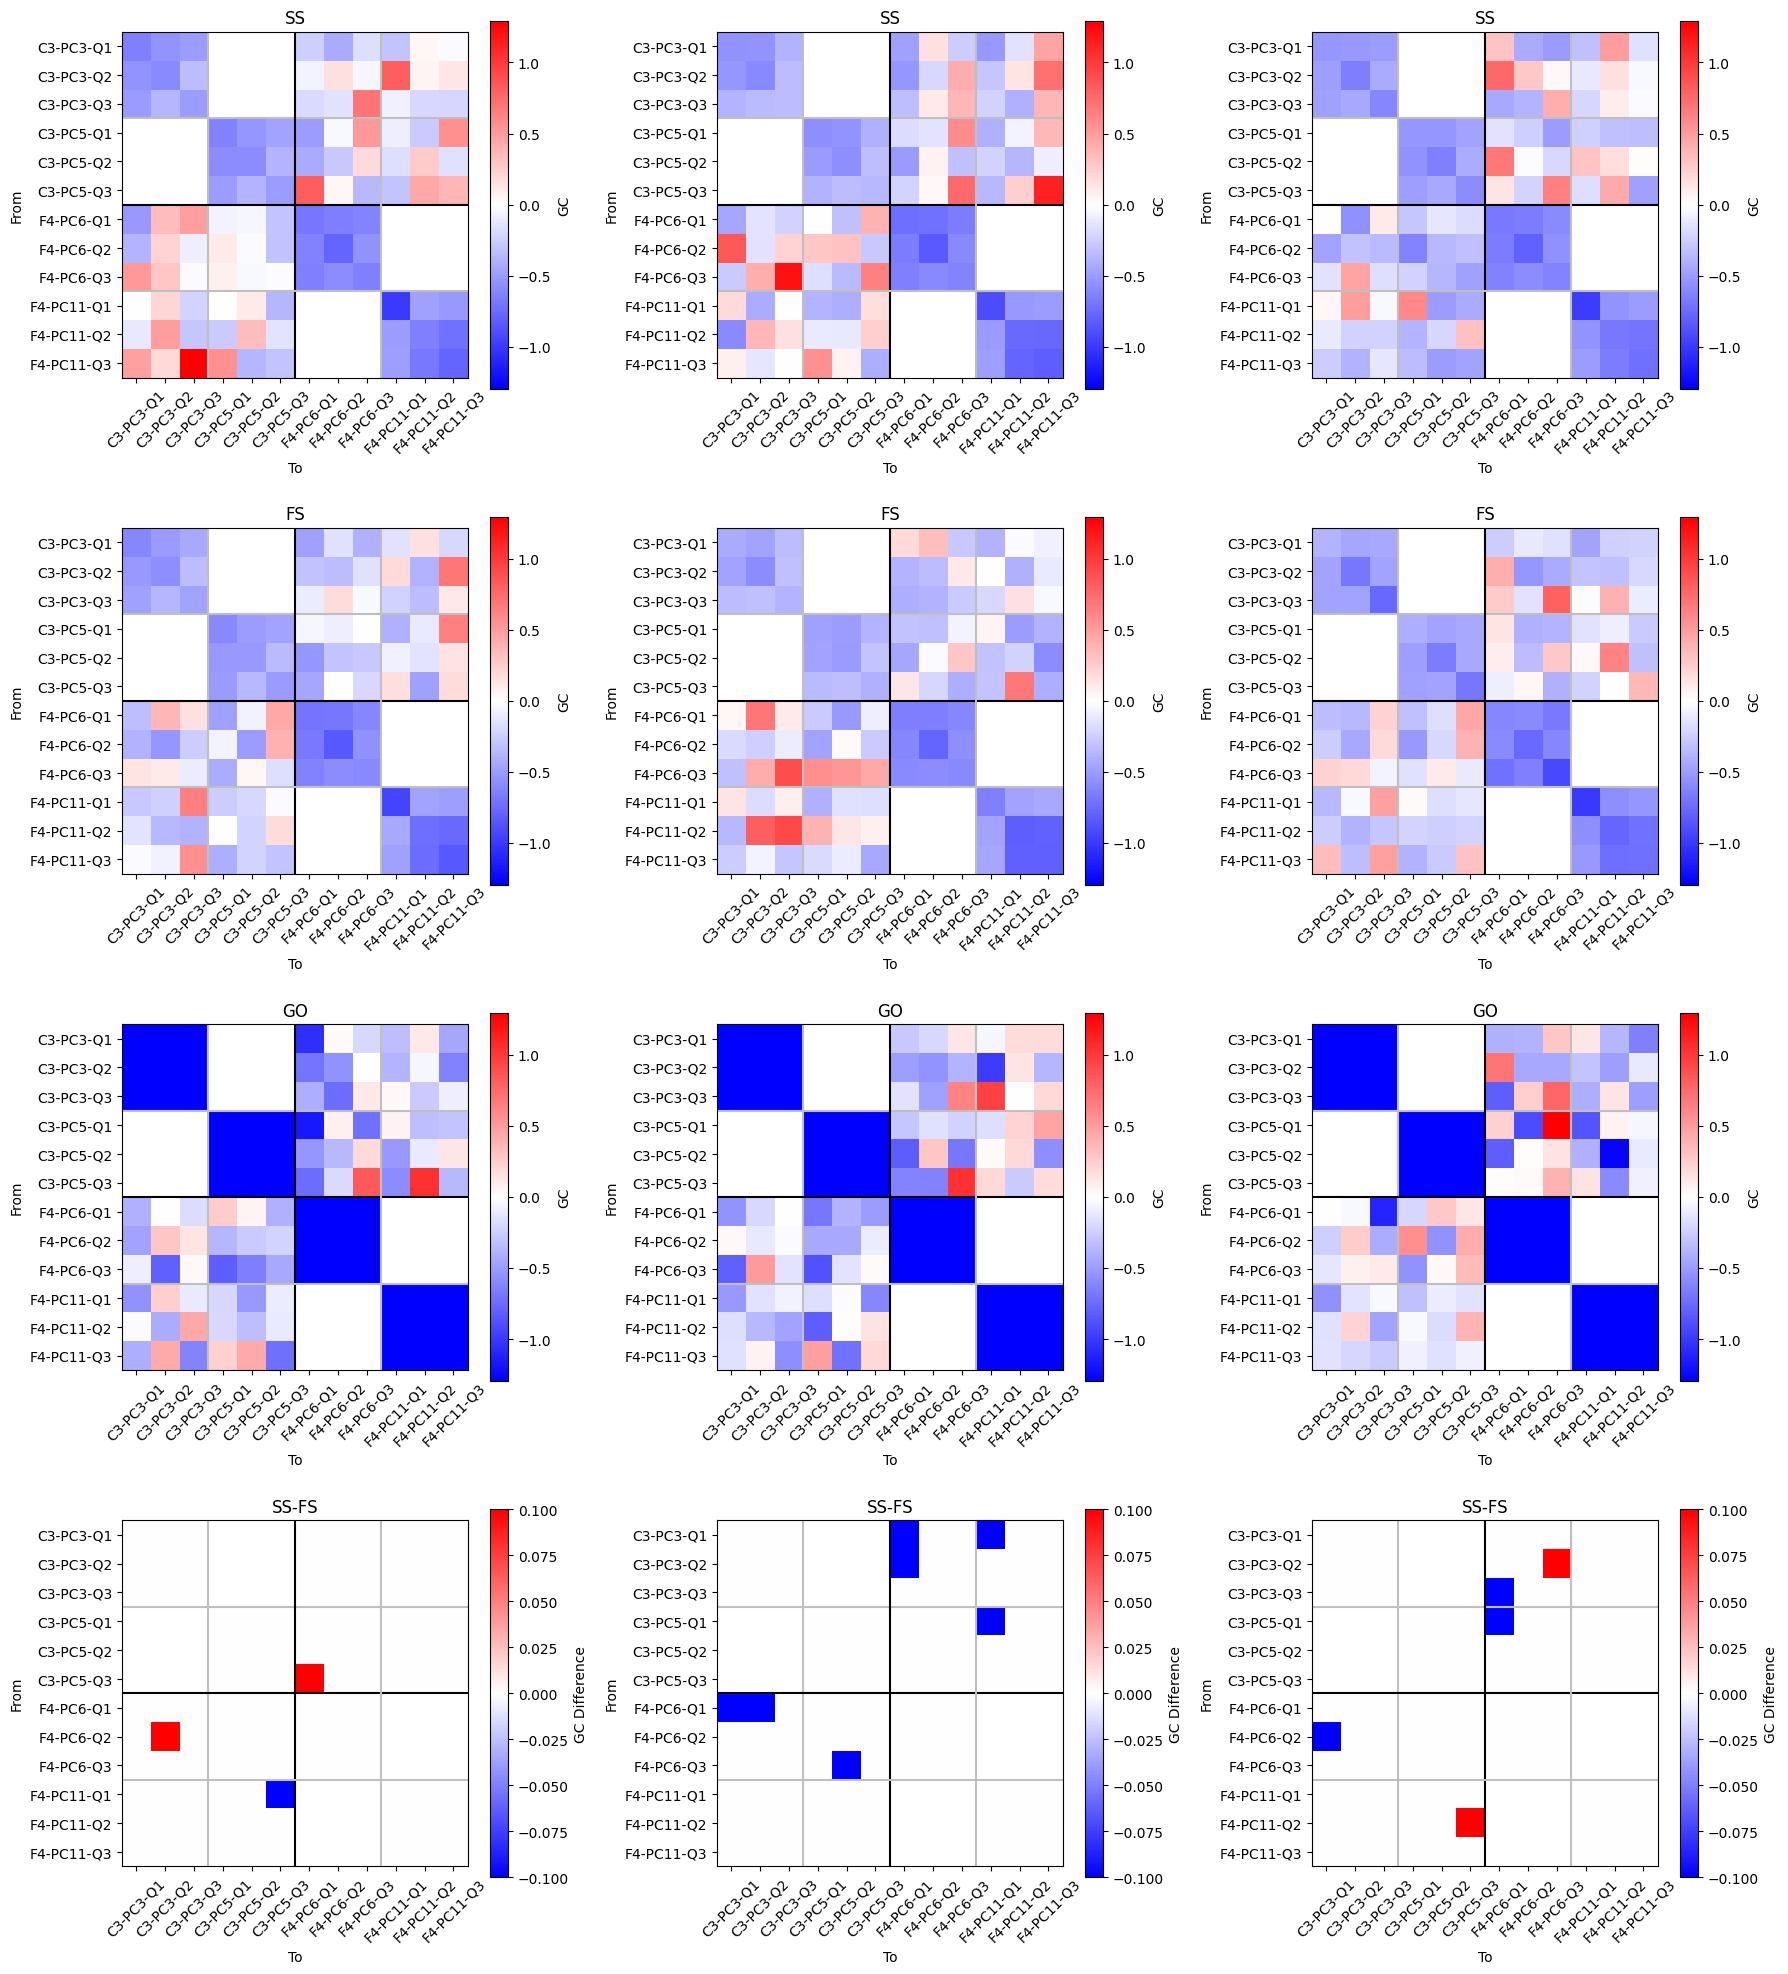

In [9]:
fig = plt.figure(figsize=(18, 20))
gs = GridSpec(4, 3)
# Calculate a dynamic clim based on all conditions
all_gc_values = []
for cond in ['FS','SS']:
    all_gc_values.extend(t1_signed_gc_matrices[cond].flatten())
    all_gc_values.extend(t2_signed_gc_matrices[cond].flatten())
    all_gc_values.extend(t3_signed_gc_matrices[cond].flatten())
common_clim = [-max(abs(np.nanmin(all_gc_values)), np.nanmax(all_gc_values)), max(abs(np.nanmin(all_gc_values)), np.nanmax(all_gc_values))]

ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(t1_signed_gc_matrices['SS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('SS')

ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(t2_signed_gc_matrices['SS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('SS')

ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(t3_signed_gc_matrices['SS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('SS')

ax = fig.add_subplot(gs[1, 0])
# Visualize results
im = ax.imshow(t1_signed_gc_matrices['FS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('FS')

ax = fig.add_subplot(gs[1, 1])
# Visualize results
im = ax.imshow(t2_signed_gc_matrices['FS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('FS')

ax = fig.add_subplot(gs[1, 2])
# Visualize results
im = ax.imshow(t3_signed_gc_matrices['FS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('FS')

ax = fig.add_subplot(gs[2, 0])
# Visualize results
im = ax.imshow(t1_signed_gc_matrices['GO'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('GO')

ax = fig.add_subplot(gs[2, 1])
# Visualize results
im = ax.imshow(t2_signed_gc_matrices['GO'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('GO')

ax = fig.add_subplot(gs[2, 2])
# Visualize results
im = ax.imshow(t3_signed_gc_matrices['GO'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('GO')

# Plot the GC difference
ax = fig.add_subplot(gs[3, 0])
significant_diff_gc_matrix = copy.copy(t1_diff_gc_matrices)
significant_diff_gc_matrix[t1_p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='bwr', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC Difference')
ax.set_title('SS-FS')

ax = fig.add_subplot(gs[3, 1])
significant_diff_gc_matrix = copy.copy(t2_diff_gc_matrices)
significant_diff_gc_matrix[t2_p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='bwr', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC Difference')
ax.set_title('SS-FS')

ax = fig.add_subplot(gs[3, 2])
significant_diff_gc_matrix = copy.copy(t3_diff_gc_matrices)
significant_diff_gc_matrix[t3_p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='bwr', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC Difference')
ax.set_title('SS-FS')

plt.tight_layout()

# plt.savefig('./figures/figure_Sxx_connectivity.pdf')

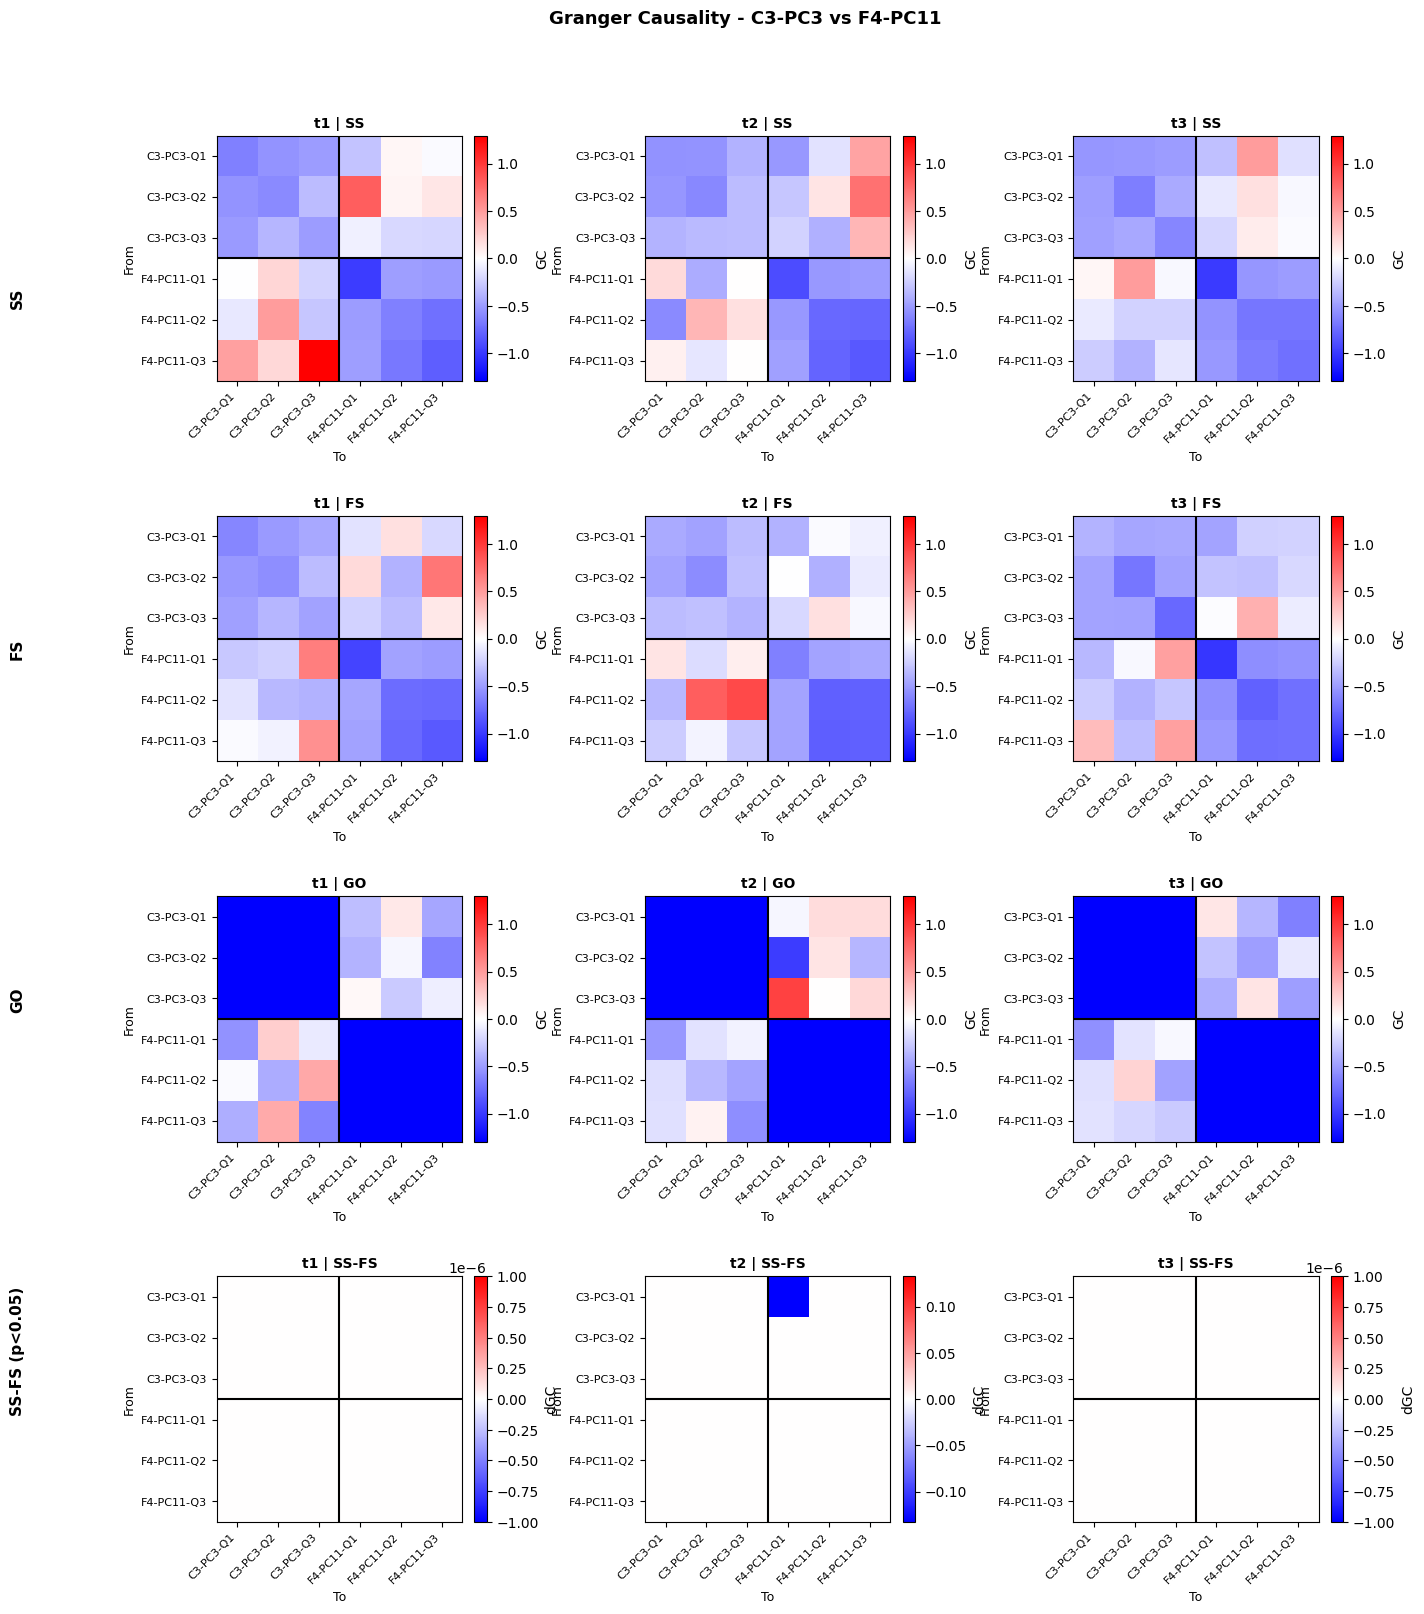

In [12]:
# target pair 
C3_PC  = 2   # 0-indexed -> PC3
F4_PC  = 10  # 0-indexed -> PC11

n_q = 3
conditions = ['GO', 'SS', 'FS']

unit_labels = (
    [f'C3-PC{C3_PC+1}-Q{q+1}' for q in range(n_q)] +
    [f'F4-PC{F4_PC+1}-Q{q+1}' for q in range(n_q)]
)
n_units = len(unit_labels)   # 6

#  helper to load one time-window file
def load_window(tag):
    fname = (f'/home/qmoreau/schmidt_data/stop_go_bursts/output/'
             f'connectivity_{tag}_c3pc{C3_PC+1}_f4pc{F4_PC+1}.npz')
    data  = np.load(fname, allow_pickle=True)

    pc_unit_labels = data['unit_labels'][()]
    pc_n           = len(pc_unit_labels)

    idx = [unit_labels.index(lbl) for lbl in pc_unit_labels]

    signed = {cond: np.full((n_units, n_units), np.nan) for cond in conditions}
    for cond in conditions:
        pc_mat = np.mean(np.array(data['signed_gc_matrices'][()][cond]), axis=0)
        for pi in range(pc_n):
            for pj in range(pc_n):
                signed[cond][idx[pi], idx[pj]] = pc_mat[pi, pj]

    diff = np.full((n_units, n_units), np.nan)
    pval = np.full((n_units, n_units), np.nan)
    pc_diff = np.mean(data['diff_gc_matrices'][()], axis=0)
    pc_pval = data['p_values_diff'][()]
    for pi in range(pc_n):
        for pj in range(pc_n):
            diff[idx[pi], idx[pj]] = pc_diff[pi, pj]
            pval[idx[pi], idx[pj]] = pc_pval[pi, pj]

    return signed, diff, pval

t1_signed, t1_diff, t1_pval = load_window('t1')
t2_signed, t2_diff, t2_pval = load_window('t2')
t3_signed, t3_diff, t3_pval = load_window('t3')

#  shared colour limits (FS + SS only)
all_vals = []
for cond in ['FS', 'SS']:
    for signed in [t1_signed, t2_signed, t3_signed]:
        all_vals.extend(signed[cond].flatten())
absmax_shared = np.nanmax(np.abs(all_vals))
common_clim   = [-absmax_shared, absmax_shared]

separator = n_q - 0.5   # 2.5

#  plotting helpers 
def draw_matrix(ax, mat, clim, title, cbar_label='GC'):
    im = ax.imshow(mat, cmap='bwr', interpolation='none', clim=clim)
    ax.set_xticks(np.arange(n_units))
    ax.set_xticklabels(unit_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(np.arange(n_units))
    ax.set_yticklabels(unit_labels, fontsize=8)
    ax.set_xlabel('To',   fontsize=9)
    ax.set_ylabel('From', fontsize=9)
    ax.axvline(separator, color='k', lw=1.5)
    ax.axhline(separator, color='k', lw=1.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, label=cbar_label, fraction=0.046, pad=0.04)

def masked_diff(diff_mat, pval_mat):
    out = copy.copy(diff_mat)
    out[pval_mat >= 0.05] = 0
    absmax = np.nanmax(np.abs(out))
    if absmax == 0:
        absmax = 1e-6
    return out, [-absmax, absmax]

#  figure
time_labels = ['t1', 't2', 't3']
windows     = [(t1_signed, t1_diff, t1_pval),
               (t2_signed, t2_diff, t2_pval),
               (t3_signed, t3_diff, t3_pval)]

fig = plt.figure(figsize=(15, 18))
gs  = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.4)

row_titles = ['SS', 'FS', 'GO', 'SS-FS (p<0.05)']

for col, (tlabel, (signed, diff, pval)) in enumerate(zip(time_labels, windows)):

    for row, cond in enumerate(['SS', 'FS', 'GO']):
        ax = fig.add_subplot(gs[row, col])
        draw_matrix(ax, signed[cond], common_clim,
                    title=f'{tlabel} | {cond}')

    ax   = fig.add_subplot(gs[3, col])
    mdat, dclim = masked_diff(diff, pval)
    draw_matrix(ax, mdat, dclim,
                title=f'{tlabel} | SS-FS', cbar_label='dGC')

for row, rtitle in enumerate(row_titles):
    fig.text(0.01, 0.79 - row * 0.195, rtitle,
             va='center', ha='left', fontsize=11,
             fontweight='bold', rotation=90)

fig.suptitle(f'Granger Causality - C3-PC{C3_PC+1} vs F4-PC{F4_PC+1}',
             fontsize=13, fontweight='bold', y=0.95)

plt.show()